# Reassemble whole optical nerve segmentation from tiles

## Setup

### Import libraries:

In [ ]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
from pathlib import Path

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


### Choose parameters:

In [2]:
## Set species here:
species = 'Du25'

save_final_data = False

### Define paths :

In [3]:
path2kdrive = "/home/jovyan/kDrive"
path2data = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/prediction", species, "tiles")
path2save = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve/prediction", species)
print(path2data)

/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/prediction/Du25/tiles


In [4]:
def tile_coordinates(path2directory, prefix='tile'):
    """ Reads in the coordinates of the predicted tiles """
    basepath = Path(path2directory)
    tiles = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.startswith(prefix) and entry.name.endswith('.png')) # generator
    tiles_names = sorted([entry.name for entry in tiles])
    tile_coords = []
    for tile in tiles_names:    
        tile_name_splitted = re.split('_|\.', tile)
        i = tile_name_splitted[1]
        j = tile_name_splitted[2]
        tile_coords.append((int(i),int(j)))
    
    return tile_coords

### Define options per species:

In [5]:
# a black placeholder to fill the borders (in order to get a proper image array)
black_tile = np.zeros((512, 512))
# specific to Hr11 image:
if species == 'Hr11':
    ncols = 19
    ltrim = 91
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((740, 10240 + ltrim))
elif species == 'Cl':
    ncols = 30
    ltrim = 0
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512, 31*512 + ltrim))
elif species == 'Aa06':
    ncols = 22
    ltrim = 200
    ttrim = 83
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, 23*512 + ltrim))
elif species == 'Aa14':
    ncols = 35
    ltrim = 126
    ttrim = 1
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, (ncols+1)*512 + ltrim))
elif species == 'Hr21':
    img_length = 11313 # original image length in px
    img_height = 8559
    ncols = 22
    nrows = 16
    ltrim =  math.floor((img_length - ncols * 512)/2)#24
    ttrim = math.ceil((img_height - nrows * 512)/2)#184
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((ttrim, (ncols+1)*512 + ltrim))
elif species == 'Cj22':
    img_length = 16875 # original image length in px
    img_height = 15984
    ncols = 32
    nrows = 31
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, (ncols+1)*512 + ltrim))
elif species == 'Mc12':
    img_length = 11232 # original image length in px
    img_height = 14280
    ncols = 21
    nrows = 27
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((ttrim, (ncols+1)*512 + ltrim))
elif species == 'Du26':
    img_length = 8556 # original image length in px
    img_height = 7788
    ncols = 16
    nrows = 15
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((ttrim, (ncols+1)*512 + ltrim))
elif species == 'Fp23':
    img_length = 25353 # original image length in px
    img_height = 23409
    ncols = 49
    nrows = 45
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, (ncols+1)*512 + ltrim))
elif species == 'Ft10':
    img_length = 19683 # original image length in px
    img_height = 20655
    ncols = 38
    nrows = 40
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, (ncols+1)*512 + ltrim))
elif species == 'Du25':
    img_length = 10368 # original image length in px
    img_height = 9477
    ncols = 20
    nrows = 18
    ltrim =  math.floor((img_length - ncols * 512)/2)
    ttrim = math.ceil((img_height - nrows * 512)/2)
    black_left_buffer = np.zeros((512, ltrim))
    black_segment_top = np.zeros((512 + ttrim, (ncols+1)*512 + ltrim))

## Import tiles and concatenate them to form a binary image of the whole optic nerve

In [6]:
tile_coords = tile_coordinates(path2data, prefix='predict')
tile_coords_sorted = sorted(tile_coords, key=lambda x: (int(x[0]), int(x[1])))

In [ ]:
## front placeholder for first row:
front_placeholder = np.concatenate([black_left_buffer, np.concatenate([black_tile for i in range(tile_coords_sorted[0][1])], axis=1)], axis=1)
print(front_placeholder.shape)
pred_tiles_all = []
## initialize with a horizontal black placeholder up to the first tile:
pred_tiles_row = [front_placeholder]
row_nb = tile_coords_sorted[0][0]
col_nb = tile_coords_sorted[0][1]
row_nb_prev = row_nb
col_nb_prev = None
for idx, tc in enumerate(tile_coords_sorted):
    print(idx, tc)
    row_nb = tc[0]
    col_nb = tc[1]
    pred_tile = import_pred_asarray(path2data, row_nb, col_nb, show_pred=False)
    if row_nb == row_nb_prev:
        if col_nb_prev is None or col_nb == col_nb_prev + 1:
            pred_tiles_row.append(pred_tile)
        elif col_nb > col_nb_prev + 1:
            pred_tiles_row.append(np.zeros((512, 512 * (col_nb - col_nb_prev - 1))))
            pred_tiles_row.append(pred_tile)
            #print('add', 512 * (col_nb - col_nb_prev - 1))           
    else: ## a new row starts:
        ## if needed, terminate the previous row by appending a black placeholder:
        if col_nb_prev < ncols:
            print(f'append {ncols - col_nb_prev} black tiles to the end of row')
            end_placeholder = np.concatenate([black_tile for i in range(ncols - col_nb_prev)], axis=1)
            pred_tiles_row.append(end_placeholder)
        ## append terminated row to the list of rows :
        pred_tiles_all.append(pred_tiles_row)
        ## if needed, create front placeholder for new row, and prepend it :
        if col_nb == 0:
            pred_tiles_row = [black_left_buffer, pred_tile]
        else:
            print(f'prepend {col_nb} black tiles to the row')
            front_placeholder = np.concatenate([black_left_buffer, np.concatenate([black_tile for i in range(col_nb)], axis=1)], axis=1)
            pred_tiles_row = [front_placeholder, pred_tile]
            
    row_nb_prev = row_nb
    col_nb_prev = col_nb
    if idx == len(tile_coords_sorted)-1:
        ## if needed, terminate the last row by appending a black placeholder:
        if col_nb < ncols:
            print(f'append {ncols - col_nb} black tiles to the end of row')
            end_placeholder = np.concatenate([black_tile for i in range(ncols - col_nb)], axis=1)
            pred_tiles_row.append(end_placeholder)
        pred_tiles_all.append(pred_tiles_row) ## append the last row
    

(512, 4672)
0 (1, 9)
1 (1, 10)
2 (1, 11)
3 (1, 12)
4 (1, 13)
5 (1, 14)
6 (1, 15)
7 (2, 7)
append 5 black tiles to the end of row
prepend 7 black tiles to the row
8 (2, 8)
9 (2, 9)
10 (2, 10)
11 (2, 11)
12 (2, 12)
13 (2, 13)
14 (2, 14)
15 (2, 15)
16 (2, 16)
17 (2, 17)
18 (3, 5)
append 3 black tiles to the end of row
prepend 5 black tiles to the row
19 (3, 6)
20 (3, 7)
21 (3, 8)
22 (3, 9)
23 (3, 10)
24 (3, 11)
25 (3, 12)
26 (3, 13)
27 (3, 14)
28 (3, 15)
29 (3, 16)
30 (3, 17)
31 (4, 4)
append 3 black tiles to the end of row
prepend 4 black tiles to the row
32 (4, 5)
33 (4, 6)
34 (4, 7)
35 (4, 8)
36 (4, 9)
37 (4, 10)
38 (4, 11)
39 (4, 12)
40 (4, 13)
41 (4, 14)
42 (4, 15)
43 (4, 16)
44 (4, 17)
45 (4, 18)
46 (5, 2)
append 2 black tiles to the end of row
prepend 2 black tiles to the row
47 (5, 3)
48 (5, 4)
49 (5, 5)
50 (5, 6)
51 (5, 7)
52 (5, 8)
53 (5, 9)
54 (5, 10)
55 (5, 11)
56 (5, 12)
57 (5, 13)
58 (5, 14)
59 (5, 15)
60 (5, 16)
61 (5, 17)
62 (5, 18)
63 (6, 2)
append 2 black tiles to the en

In [8]:
concat_by_cols = [black_segment_top]
for r in pred_tiles_all:
    #print([a.shape for a in r])
    concat_by_cols.append(np.concatenate(r, axis=1))
whole_predicted_mask = np.concatenate(concat_by_cols, axis=0)

(8835, 10816)


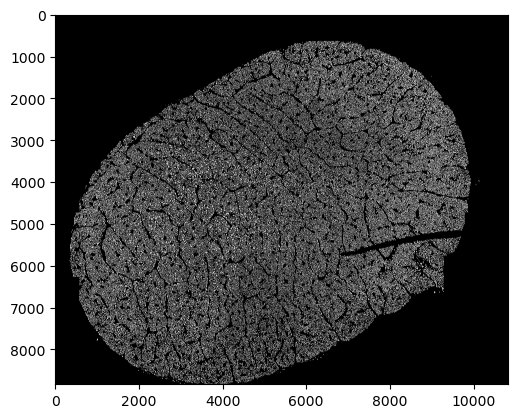

In [9]:
plt.imshow(whole_predicted_mask, cmap='gray', vmin=0, vmax=255)
print(whole_predicted_mask.shape)

In [10]:
if save_final_data:
    print(f"save reassembled whole raw mask to {path2save}")
    img = Image.fromarray(whole_predicted_mask.astype(np.uint8))
    img.save(os.path.join(path2save, 'predicted_raw_mask.png'))


## Convert raw mask to a binary mask

In [11]:
binary_thr = 150
whole_predicted_mask_binary = np.zeros(whole_predicted_mask.shape)
whole_predicted_mask_binary[whole_predicted_mask > binary_thr] = 255
whole_predicted_mask_binary[whole_predicted_mask <= binary_thr] = 0

In [12]:
if save_final_data:
    print(f"save whole binary mask to {path2save}")
    img_binary = Image.fromarray(whole_predicted_mask_binary.astype(np.uint8))
    img_binary.save(os.path.join(path2save, 'predicted_binary_mask.png'))